<a href="https://colab.research.google.com/github/ii-shimul/ingeet/blob/mahin/LSTM_Model_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Loading Preprocessed Dataset

The dataset was preprocessed in the Data Acquisition and Preprocessing
notebook. The saved NumPy files are loaded here to prepare the data
for LSTM model development.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np

data_path = "/content/drive/MyDrive/Ishara/processed_data"

X_train = np.load(data_path + "/X_train.npy")
y_train = np.load(data_path + "/y_train.npy")

X_val = np.load(data_path + "/X_val.npy")
y_val = np.load(data_path + "/y_val.npy")

X_test = np.load(data_path + "/X_test.npy")
y_test = np.load(data_path + "/y_test.npy")

class_names = np.load(
    data_path + "/class_names.npy",
    allow_pickle=True
)

In [3]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("Number of classes:", len(class_names))

X_train: (6514, 44, 258)
y_train: (6514,)
X_val: (1396, 44, 258)
y_val: (1396,)
X_test: (1397, 44, 258)
y_test: (1397,)
Number of classes: 60


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [5]:
model = Sequential()

In [6]:
model = Sequential([
    Input(shape=(44, 258)),

    LSTM(128, return_sequences=True),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(60, activation='softmax')
])

In [7]:
model.summary()
print("\nModel output shape:", model.output_shape)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 44, 128)        │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 44, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 60)             │         1,980 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,948 (1023.23 KB)

 Trainable params: 261,948 (1023.23 KB)

 Non-trainable params: 0 (0.00 B)


Model output shape: (None, 60)


In [8]:
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Model Training

The compiled LSTM model is trained using the training dataset.
The validation dataset is used to monitor model performance
during training.

In [22]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - accuracy: 0.9100 - loss: 0.3284 - val_accuracy: 0.8489 - val_loss: 0.4865
Epoch 2/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.9071 - loss: 0.3322 - val_accuracy: 0.8754 - val_loss: 0.4046
Epoch 3/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - accuracy: 0.9070 - loss: 0.3267 - val_accuracy: 0.8546 - val_loss: 0.4676
Epoch 4/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.9163 - loss: 0.2980 - val_accuracy: 0.8861 - val_loss: 0.3925
Epoch 5/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - accuracy: 0.9326 - loss: 0.2523 - val_accuracy: 0.8961 - val_loss: 0.3577
Epoch 6/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.9269 - loss: 0.2616 - val_accuracy: 0.8897 - val_loss: 0.3846
Epoch 7/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - accuracy: 0.8998 - loss: 0.3360 - val_accuracy: 0.8797 - val_loss: 0.4028
Epoch 8/50
204/204 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - accuracy: 0.9182 - loss: 0.2898 - 

In [23]:
print("Final Training Accuracy:",
      history.history["accuracy"][-1])

print("Final Validation Accuracy:",
      history.history["val_accuracy"][-1])

Final Training Accuracy: 0.9654589891433716
Final Validation Accuracy: 0.8724928498268127


## Training and Validation Performance

The training history is visualized to compare model performance
on the training and validation datasets across epochs.

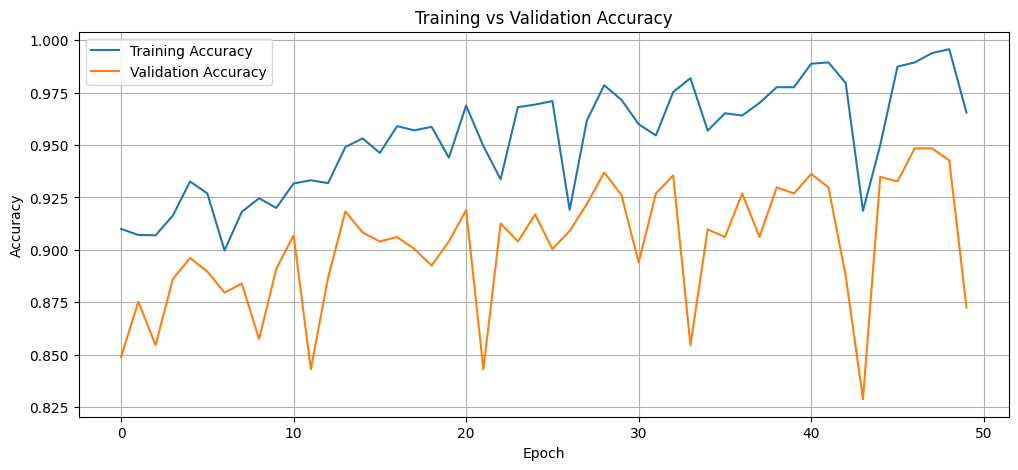

In [24]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

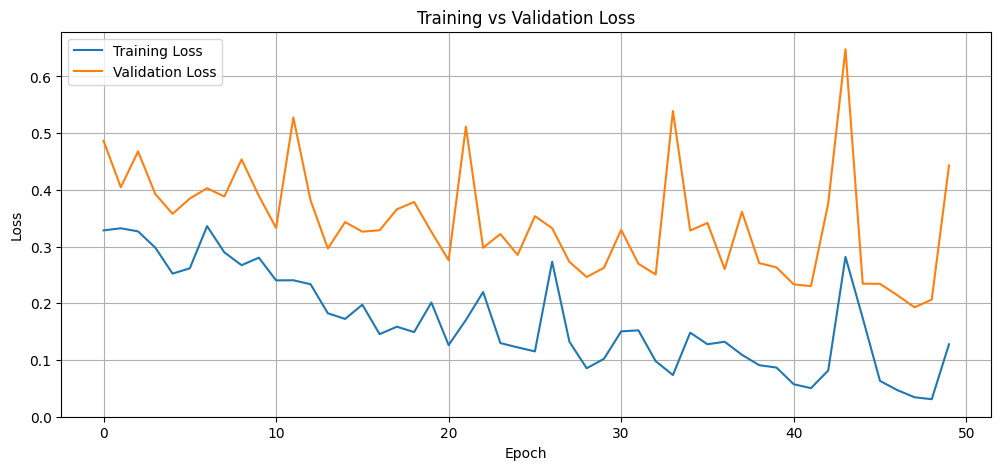

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Training and Validation Performance Analysis

### Experiment 1 — Initial Training

* **Model:** Incorrect configuration with two `Dense(60)` layers
* **Epochs:** 20
* **Training Accuracy:** 9.53%
* **Validation Accuracy:** 9.03%
* **Training Loss:** 3.2519
* **Validation Loss:** 3.2920
* **Result:** Treated as an initial/incorrect experiment due to the duplicate Dense layer.

### Experiment 2 — Corrected Training

* **Model:** Three LSTM layers + single `Dense(60, activation='softmax')`
* **Epochs:** 20
* **Training Accuracy:** 67.36%
* **Validation Accuracy:** 67.84%
* **Training Loss:** 1.0817
* **Validation Loss:** 1.0896

### Experiment 3 — Improved Training

* **Model:** Same corrected architecture
* **Epochs:** 20
* **Training Accuracy:** 89.85%
* **Validation Accuracy:** 85.74%
* **Training Loss:** 0.3659
* **Validation Loss:** 0.4841

### Experiment 4 — Extended Training

* **Model:** Same corrected architecture
* **Epochs:** 50
* **Training Accuracy:** 96.55%
* **Validation Accuracy:** 87.25%
* **Training Loss:** 0.1277
* **Validation Loss:** 0.4430
* **Test Accuracy:** 88.76%
* **Test Loss:** 0.4179
* **Best Validation Accuracy:** 94.84% at Epoch 47 and 48
* **Best Validation Loss:** 0.1929 at Epoch 48

### Overall Observation

The model improved significantly across the experiments, with test accuracy increasing from **67.57% in Experiment 2** to **85.54% in Experiment 3** and **88.76% in Experiment 4**. The 50-epoch experiment achieved its best validation performance around Epoch 48, but the performance dropped at Epoch 50, showing that the model's validation performance fluctuated during extended training.


In [26]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8876 - loss: 0.4179
Test Loss: 0.4178580343723297
Test Accuracy: 0.8876163363456726


### Test Set Evaluation

#### Experiment 1 — Initial Model

* **Test Samples:** 1,397
* **Test Accuracy:** 9.52%
* **Test Loss:** 3.2687
* **Result:** Baseline performance of the initial model with the incorrect duplicate Dense layer.

#### Experiment 2 — Corrected Model

* **Test Samples:** 1,397
* **Test Accuracy:** 67.57%
* **Test Loss:** 1.0671
* **Training Accuracy:** 67.36%
* **Validation Accuracy:** 67.84%

#### Experiment 3 — Improved Training

* **Test Samples:** 1,397
* **Test Accuracy:** 85.54%
* **Test Loss:** 0.4929
* **Training Accuracy:** 89.85%
* **Validation Accuracy:** 85.74%

#### Experiment 4 — Extended Training

* **Test Samples:** 1,397
* **Test Accuracy:** 88.76%
* **Test Loss:** 0.4179
* **Training Accuracy:** 96.55%
* **Validation Accuracy:** 87.25%
* **Best Validation Accuracy:** 94.84% at Epoch 47 and 48

### Overall Observation

The test accuracy improved across the experiments from **9.52% → 67.57% → 85.54% → 88.76%**. The extended 50-epoch training produced the highest test accuracy in these experiments, while the best validation accuracy was achieved at Epoch 47 and 48.


In [14]:
model.save("ishara_lstm_baseline.keras")

In [15]:
from google.colab import files

files.download("ishara_lstm_baseline.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>